In [151]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [152]:
from google.colab import files
uploaded = files.upload()

Saving airbnb_listings.xlsx to airbnb_listings (3).xlsx


In [153]:
df = pd.read_excel("airbnb_listings.xlsx")

# **EDA STEPS**

In [154]:
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaT,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaT,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaT,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [155]:
df.tail()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
30473,43022976,2015-08-31,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30474,42993382,2015-08-31,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30475,43033067,2015-08-31,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30476,43000991,2015-08-31,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN
30477,42999189,2015-08-31,Huge Beautiful Bedroom - Astoria,Queens,House,NaN,Private room,11105.0,1.0,1,0,80,NaN


In [156]:
df.shape

(30478, 13)

In [157]:
df.columns

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30478 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30478 non-null  object        
 3   Neighbourhood               30478 non-null  object        
 4   Property Type               30475 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30478 non-null  object        
 7   Zipcode                     30344 non-null  float64       
 8   Beds                        30393 non-null  float64       
 9   Number of Records           30478 non-null  int64         
 10  Number Of Reviews           30478 non-null  int64         
 11  Price                       30478 non-null  int64     

In [159]:
df.describe()

,Host Id,Host Since,Review Scores Rating (bin),Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
count,3.047800e+04,30475,22155.000000,30344.000000,30393.000000,30478.0,30478.000000,30478.000000,22155.000000
mean,1.273171e+07,2013-06-29 17:56:15.317473280,90.738659,10584.854831,1.530089,1.0,12.018735,163.589737,91.993230
min,5.000000e+02,2008-06-26 00:00:00,20.000000,1003.000000,0.000000,1.0,0.000000,10.000000,20.000000
25%,2.701298e+06,2012-06-21 00:00:00,85.000000,10017.000000,1.000000,1.0,0.000000,80.000000,89.000000
50%,8.551693e+06,2013-09-01 00:00:00,90.000000,10065.000000,1.000000,1.0,3.000000,125.000000,94.000000
75%,2.120617e+07,2014-09-12 00:00:00,100.000000,11216.000000,2.000000,1.0,13.000000,195.000000,100.000000
max,4.303307e+07,2015-08-31 00:00:00,100.000000,99135.000000,16.000000,1.0,257.000000,10000.000000,100.000000
std,1.190270e+07,NaN,9.059519,921.299397,1.015359,0.0,21.980703,197.785454,8.850373


In [160]:
df.isnull().sum()

,0
Host Id,0
Host Since,3
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8323
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


In [161]:
df.duplicated().sum()

np.int64(17)

In [162]:
df = df.drop_duplicates()

In [163]:
df.shape

(30461, 13)

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30461 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30461 non-null  int64         
 1   Host Since                  30458 non-null  datetime64[ns]
 2   Name                        30461 non-null  object        
 3   Neighbourhood               30461 non-null  object        
 4   Property Type               30458 non-null  object        
 5   Review Scores Rating (bin)  22152 non-null  float64       
 6   Room Type                   30461 non-null  object        
 7   Zipcode                     30327 non-null  float64       
 8   Beds                        30376 non-null  float64       
 9   Number of Records           30461 non-null  int64         
 10  Number Of Reviews           30461 non-null  int64         
 11  Price                       30461 non-null  int64         


In [165]:
df_copy = df

In [166]:
# Handling null values

df['Beds'].fillna(df['Beds'].median(), inplace=True)

df['Review Scores Rating'].fillna(df['Review Scores Rating'].mean(), inplace=True)

df['Property Type'].fillna(df['Property Type'].mode()[0], inplace=True)   # as it is categorical

df['Host Since'].fillna(df['Host Since'].mode()[0], inplace=True)

print(df.isnull().sum())

Host Id                          0
Host Since                       0
Name                             0
Neighbourhood                    0
Property Type                    0
Review Scores Rating (bin)    8309
Room Type                        0
Zipcode                        134
Beds                             0
Number of Records                0
Number Of Reviews                0
Price                            0
Review Scores Rating             0
dtype: int64


/tmp/ipython-input-2691113332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Beds'].fillna(df['Beds'].median(), inplace=True)
/tmp/ipython-input-2691113332.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

### **HYPOTHESIS: “Entire homes/apartments are more expensive than private or shared rooms, and within each room type, certain property types (like Apartments vs Houses vs Lofts) command higher prices.”**:

In [167]:
# Remove the column which are of no need
df.drop(columns=['Review Scores Rating (bin)'], inplace=True)

df.drop(columns=['Zipcode'], inplace=True)

In [168]:
df.head(10)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Room Type,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,2014-02-10,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,Entire home/apt,1.0,1,0,145,91.993048
1,33134899,2014-02-10,"Sunny, Private room in Bushwick",Brooklyn,Apartment,Private room,1.0,1,1,37,91.993048
2,39608626,2014-02-10,Sunny Room in Harlem,Manhattan,Apartment,Private room,1.0,1,1,28,91.993048
3,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,Entire home/apt,3.0,1,0,199,91.993048
4,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,Private room,3.0,1,39,549,96.000000
5,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,Entire home/apt,1.0,1,4,149,100.000000
6,1783,2008-08-12,Amazing Also,Manhattan,Apartment,Entire home/apt,1.0,1,9,250,100.000000
7,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,Private room,1.0,1,80,90,94.000000
8,2339,2008-08-20,East Village Cocoon: 2 Bedroom Flat,Manhattan,Apartment,Entire home/apt,2.0,1,95,270,90.000000
9,2339,2008-08-20,Lovely 2 Bedroom East Village Nest,Manhattan,Apartment,Entire home/apt,2.0,1,23,290,96.000000


# **UNIVARIATE ANALYSIS**

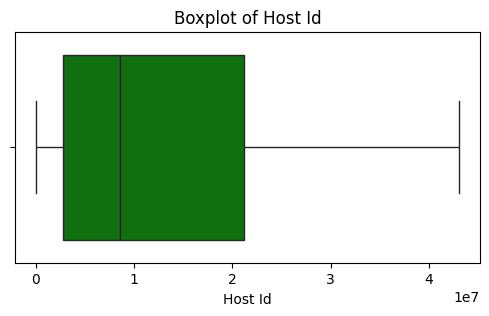

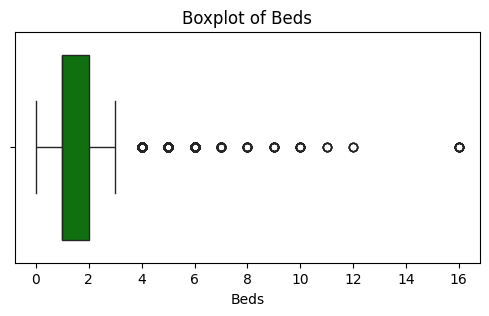

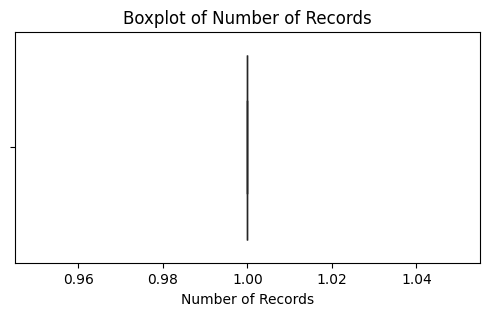

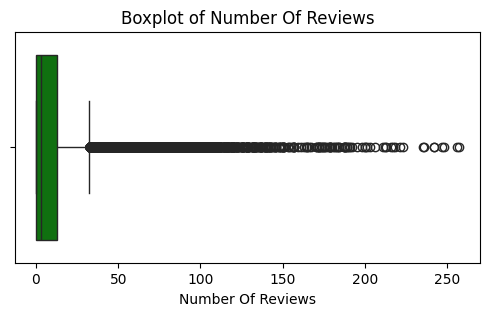

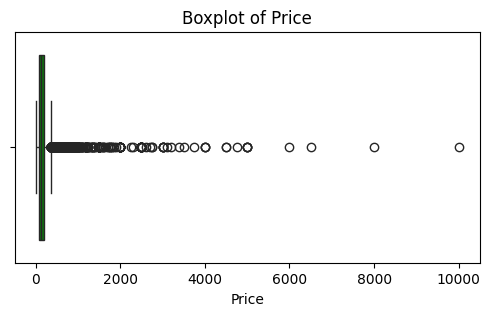

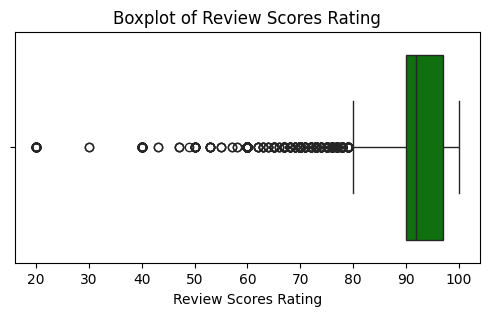

In [169]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='green')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


Q1: 81.0
Q3: 195.0
IQR: 114.0

Lower Bound: -90.0
Upper Bound: 366.0


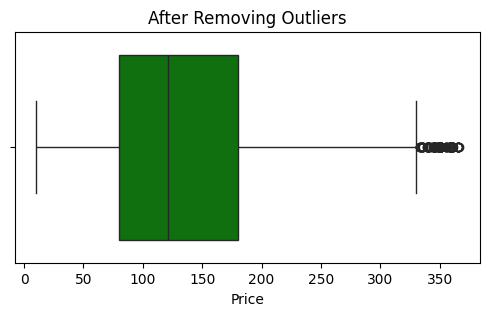

In [170]:
# Removing outliers through IQR method
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# Finding upper & lower bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Now removing them
outliers_free = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

# Boxplots again
plt.figure(figsize=(6, 3))
sns.boxplot(x=outliers_free['Price'], color='green')
plt.title("After Removing Outliers")

plt.show()

In [171]:
Q2 = df['Price'].quantile(0.50)
Q2

np.float64(125.0)

In [172]:
df = outliers_free

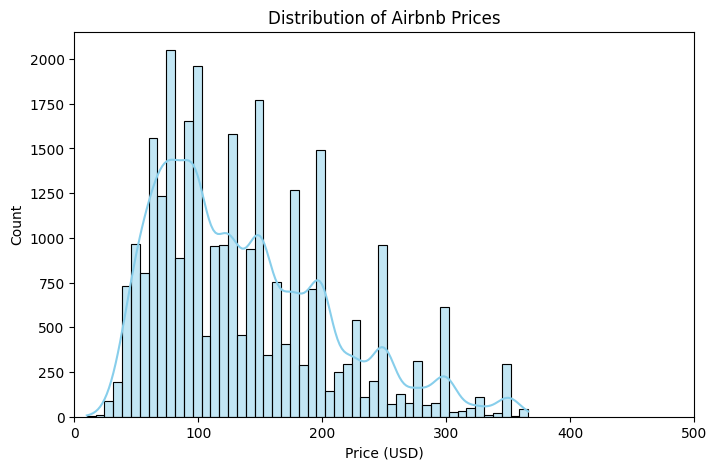

In [173]:
plt.figure(figsize=(8,5))
ax = sns.histplot(df['Price'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.xlim(0, 500)  # limit to remove extreme outliers
plt.show()

In [174]:
num_bins = 50
data_ink = num_bins + 1  # bars + smooth curve (kde)

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Distribution of Airbnb Prices':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Distribution of Airbnb Prices': 0.614


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.

/tmp/ipython-input-3129992395.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Room Type', data=df, palette='Set2')


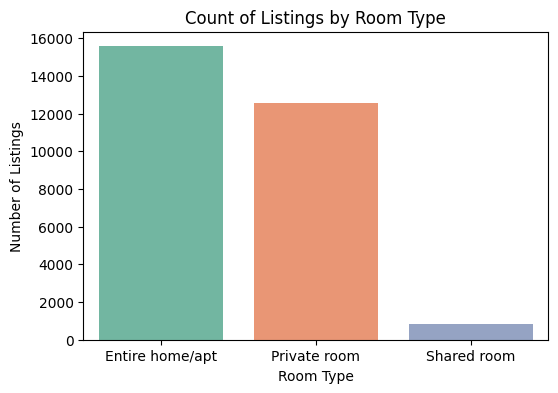

In [175]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Room Type', data=df, palette='Set2')
plt.title("Count of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.show()

In [176]:
num_bars = df['Room Type'].nunique()
data_ink = num_bars

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Count of Listings by Room Type':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Count of Listings by Room Type': 0.103


Graphical integrity is weaker as the visualization uses excessive ink for gridlines, labels, or colors, reducing efficiency.

/tmp/ipython-input-1122241319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Property Type', data=df, palette='Set2')


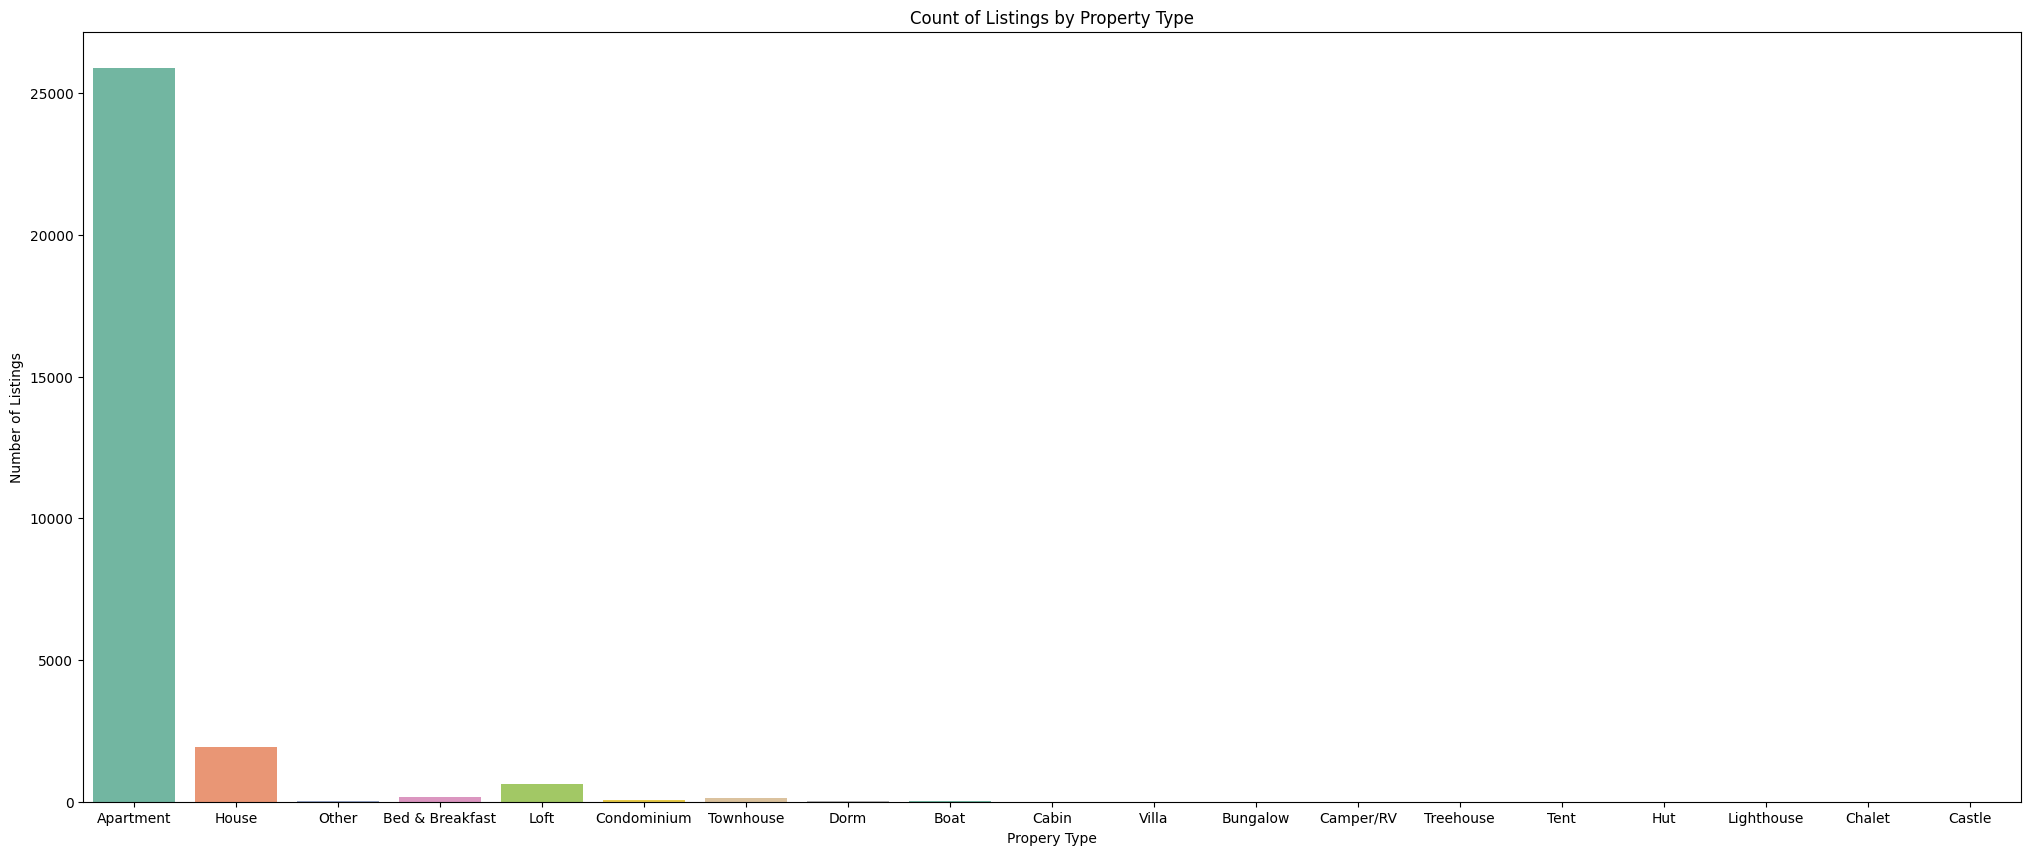

In [177]:
plt.figure(figsize=(25,10))
ax = sns.countplot(x='Property Type', data=df, palette='Set2')
plt.title("Count of Listings by Property Type")
plt.xlabel("Propery Type")
plt.ylabel("Number of Listings")
plt.show()

In [178]:
num_bars = df['Property Type'].nunique()
data_ink = num_bars

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Count of Listings by Property Type':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Count of Listings by Property Type': 0.268


Graphical integrity is weaker as the visualization uses excessive ink for gridlines, labels, or colors, reducing efficiency.

# **BIVARIATE ANALYSIS**

/tmp/ipython-input-2987146109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Room Type', y='Price', data=df, palette='Pastel2')


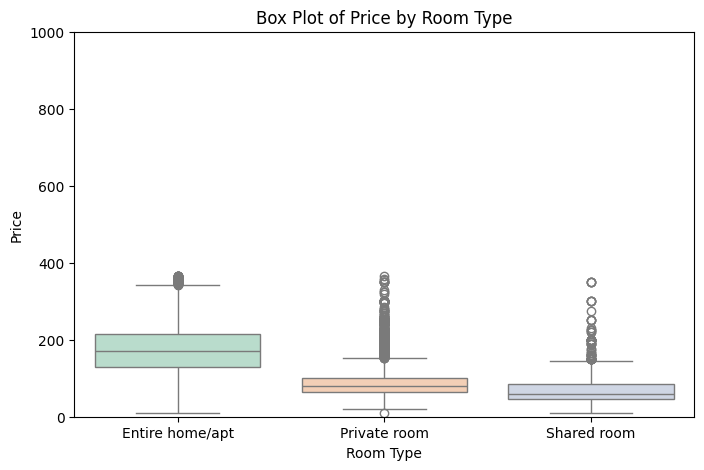

In [179]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Room Type', y='Price', data=df, palette='Pastel2')
plt.ylim(0, 1000)  # To hide extreme outliers for better visuals
plt.title("Box Plot of Price by Room Type")
plt.show()

In [180]:
# Data Ink
# for each Room Type we have 5 visible boxplot elements (box, median line, whiskers, caps)
num_room_types = df['Room Type'].nunique()
data_ink = num_room_types * 5  # 5 main parts per box

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Box Plot of Price by Room Type':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Box Plot of Price by Room Type': 0.455


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.

         Room Type       Price
0  Entire home/apt  178.109127
1     Private room   89.080769
2      Shared room   73.415865


/tmp/ipython-input-3397944995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Room Type', y='Price', data=avg_price, palette='Set2')


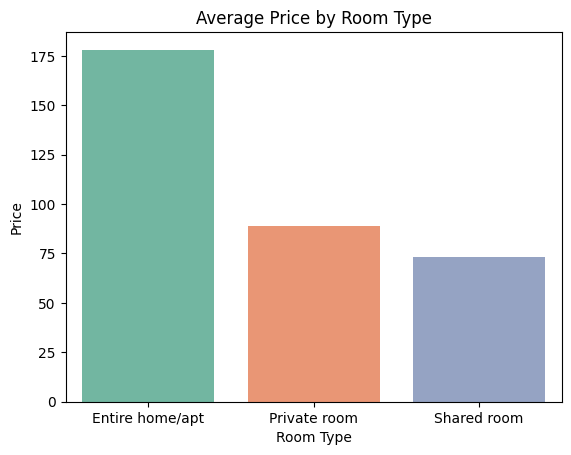

In [181]:
avg_price = df.groupby('Room Type')['Price'].mean().reset_index()
print(avg_price)
ax = sns.barplot(x='Room Type', y='Price', data=avg_price, palette='Set2')
plt.title("Average Price by Room Type")
plt.show()

In [182]:
# Data Ink
# one bar per Room Type
num_bars = avg_price.shape[0]
data_ink = num_bars

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Average Price by Room Type':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Average Price by Room Type': 0.111


Graphical integrity is weaker as the visualization uses excessive ink for gridlines, labels, or colors, reducing efficiency.

# **MULTIVARIATE ANALYSIS**

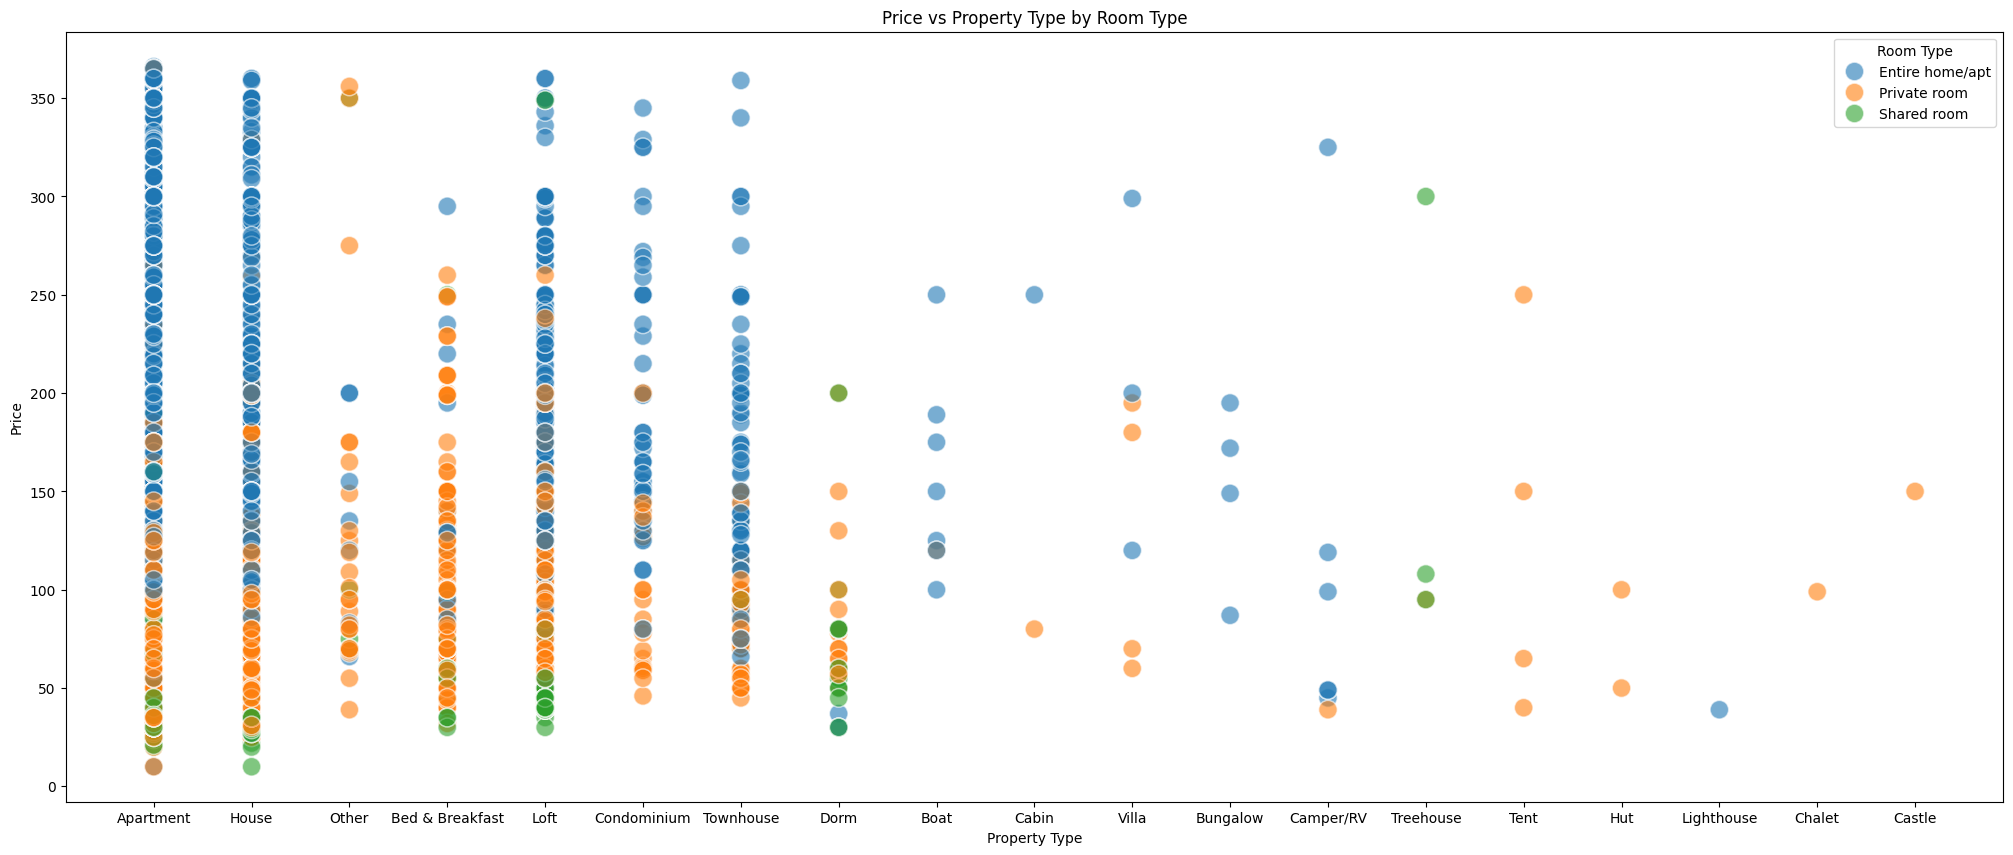

In [183]:
plt.figure(figsize=(25,10))
ax = sns.scatterplot(x='Property Type', y='Price', hue='Room Type', data=df, alpha=0.6, s=180)
plt.title("Price vs Property Type by Room Type")
plt.show()

In [184]:
# Data Ink
# each scatter point represents one listing (data point)
num_points = len(df)
data_ink = num_points

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Price vs Property Type by Room Type':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Price vs Property Type by Room Type': 0.998


Graphical integrity is strong,the distribution and key features are clearly conveyed without distraction.

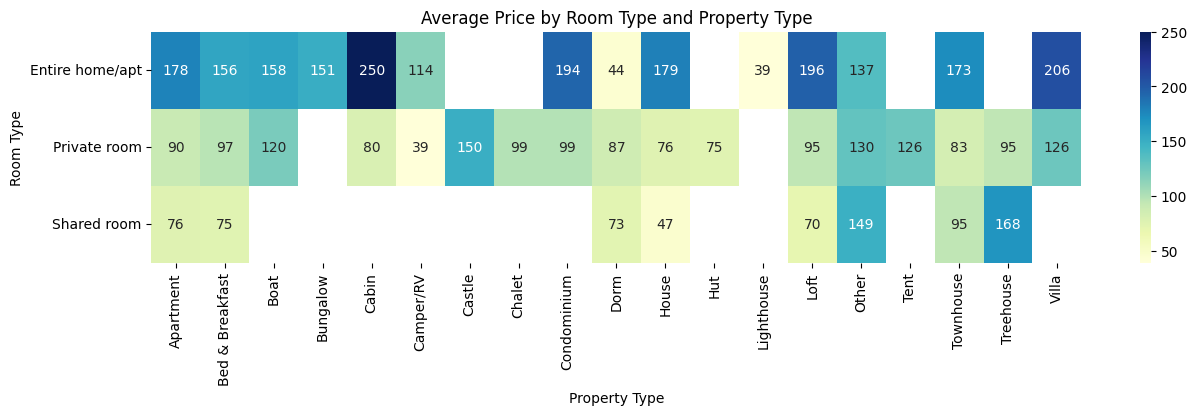

In [185]:
pivot_table = df.pivot_table(values='Price', index='Room Type', columns='Property Type', aggfunc='mean')
plt.figure(figsize=(15,3))
ax = sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Average Price by Room Type and Property Type")
plt.show()

In [186]:
# Data Ink
# each cell in the heatmap represents a data point
num_cells = pivot_table.shape[0] * pivot_table.shape[1]
data_ink = num_cells

# Non-data elements
num_texts = len(ax.texts)                 # includes annotations + title text
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Average Price by Room Type and Property Type (Heatmap)':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Average Price by Room Type and Property Type (Heatmap)': 0.407


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.

/tmp/ipython-input-382832977.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Property Type', y='Price', hue='Room Type', data=df, ci=None)


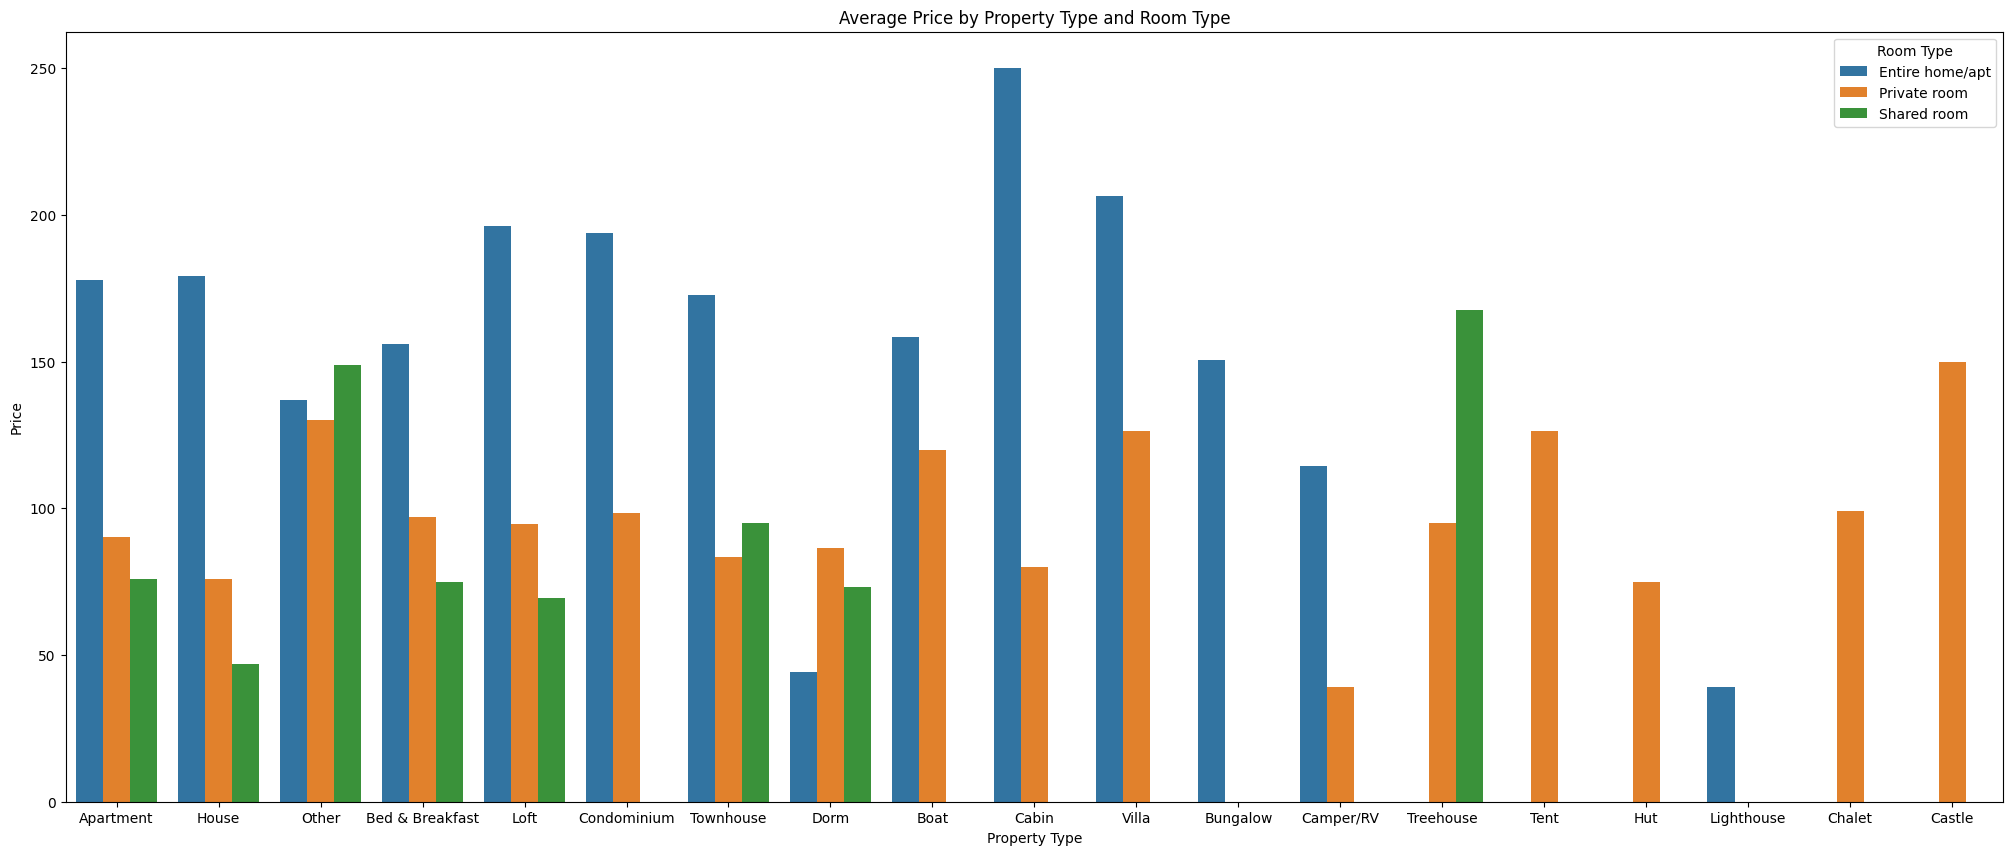

In [187]:
plt.figure(figsize=(25,10))
ax = sns.barplot(x='Property Type', y='Price', hue='Room Type', data=df, ci=None)
plt.title("Average Price by Property Type and Room Type")
plt.show()

In [188]:
# Data Ink
# one bar per Property Type–Room Type combination
num_property_types = df['Property Type'].nunique()
num_room_types = df['Room Type'].nunique()
data_ink = num_property_types * num_room_types

# Non-data elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines
data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Average Price by Property Type and Room Type (Grouped Bar Plot)':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Average Price by Property Type and Room Type (Grouped Bar Plot)': 0.523


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.